<a href="https://colab.research.google.com/github/shivampatle2004/Machine-Learning-/blob/main/LightGBM_shivam_CS23186.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Machine Learning Experiment: Breast Cancer Prediction with LightGBM



### 1. & 2. Load Breast Cancer Dataset and Import Required Libraries

In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import lightgbm as lgb

# Load the Breast Cancer dataset
breast_cancer = load_breast_cancer()


In [15]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


### Specify Custom Dataset Details



In [18]:
# --- Custom Data Loading Configuration --- #

# Provide the full path to your CSV file in Google Drive
csv_file_path = "/content/drive/MyDrive/ml_dataset/BreastCancer.csv" # @param {type:"string"}

# Specify the name of your target (dependent) column in the CSV
target_column_name = "diagnosis" # @param {type:"string"}

# Optionally, define names for your target classes for better visualization in plots.
# For example, if your target column has values 0 and 1, you can set:
# custom_class_names = ["Negative", "Positive"]
# If not provided, generic labels ('Class 0', 'Class 1') will be used in some plots.
custom_class_names = ["Malignant", "Benign"] # @param {type:"raw"}

# Declare target_names_for_plot as global at the top level of the cell to avoid SyntaxError
global target_names_for_plot

# --- Load Custom Dataset --- #
try:
    df = pd.read_csv(csv_file_path)
    print(f"Columns in the loaded dataset: {df.columns.tolist()}") # Added for debugging

    # Drop irrelevant columns like 'id' and 'Unnamed: 32' if they exist
    columns_to_drop = ['id', 'Unnamed: 32']
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

    # Separate features (X) and target (y) based on the specified target_column_name
    if target_column_name in df.columns:
        # Map 'M' and 'B' to 0 and 1 if 'diagnosis' is the target and contains these values
        if target_column_name == 'diagnosis' and df[target_column_name].dtype == 'object':
            df[target_column_name] = df[target_column_name].map({'M': 0, 'B': 1})
            print("Mapped 'M' to 0 and 'B' to 1 in the target column.")

        X = df.drop(target_column_name, axis=1)
        y = df[target_column_name]
        print(f"Custom dataset loaded successfully from '{csv_file_path}'.")
        print(f"Features (X) shape: {X.shape}, Target (y) shape: {y.shape}")

        # Override breast_cancer.target_names for plotting if custom_class_names are provided
        # Ensure this variable is available for later plotting steps.
        if custom_class_names and len(custom_class_names) == len(y.unique()):
            target_names_for_plot = custom_class_names
            print(f"Custom class names set for plotting: {target_names_for_plot}")
        else:
            # Fallback to generic names if custom_class_names are not suitable
            target_names_for_plot = [f'Class {i}' for i in sorted(y.unique())]
            print(f"Warning: custom_class_names not suitable or provided. Using generic labels for plotting: {target_names_for_plot}")

    else:
        raise ValueError(f"Target column '{target_column_name}' not found in the custom dataset.")

except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred while loading the custom dataset: {e}")

# --- Instructions for using custom data --- #
print("\n--- IMPORTANT --- ")
print("To use this custom data, you should now:")
print("1. **Comment out or delete** the original `breast_cancer = load_breast_cancer()` line in the imports cell (Cell `23ad3a8d`).")
print("2. **Comment out or delete** the original `df` creation lines that use `breast_cancer.data` and `breast_cancer.target` (Cell `a63327f3`).")
print("3. **Run this new cell** to load your custom data.")
print("4. **Modify the plotting cell** (`cell_92cfedc1`) to use `target_names_for_plot` for `xticklabels` and `yticklabels` in the `sns.heatmap` calls. For example, change `xticklabels=breast_cancer.target_names` to `xticklabels=target_names_for_plot`.")

Columns in the loaded dataset: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']
Mapped 'M' to 0 and 'B' to 1 in the target column.
Custom dataset loaded successfully from '/content/drive/MyDrive/ml_dataset/BreastCancer.csv'.
Features (X) shape: (569, 30), Target (y) shape: (569,)
Custom class names set for plotting: ['Malignant', 'Benign']

--- IMPORTANT --- 
To use this custom data, you should now:
1. **Comment out or delete** the original `breast_cancer = load_br

### 3. Convert Dataset into DataFrame

In [21]:
# Create a DataFrame from the dataset
df = pd.DataFrame(data=breast_cancer.data, columns=breast_cancer.feature_names)
df['target'] = breast_cancer.target

print("Dataset loaded and converted to DataFrame successfully.")


Dataset loaded and converted to DataFrame successfully.


### 4. Perform Basic Data Analysis


Shape of the DataFrame: (569, 31)

Info about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se      

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.627417,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,1.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Missing values in each column:


,Missing Values
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0



Class distribution of the target variable:


,Count
diagnosis,
1,357
0,212


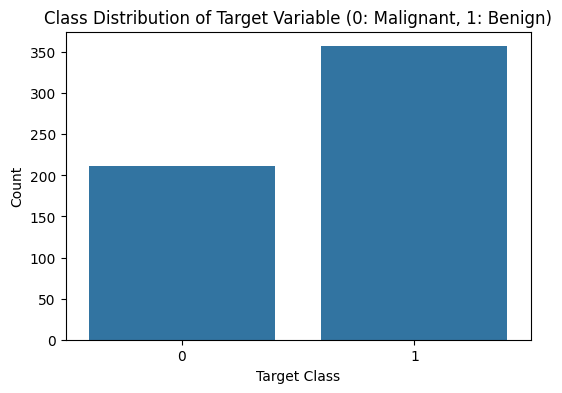

In [20]:
# Display the shape of the DataFrame
print("\nShape of the DataFrame:", df.shape)

# Display basic information about the DataFrame
print("\nInfo about the DataFrame:")
df.info()

# Display descriptive statistics of the DataFrame
print("\nDescriptive statistics of the DataFrame:")
display(df.describe())

# Check for missing values
print("\nMissing values in each column:")
display(df.isnull().sum().to_frame(name='Missing Values'))

# Check class distribution of the target variable
print("\nClass distribution of the target variable:")
display(df[target_column_name].value_counts().to_frame(name='Count'))

# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=target_column_name, data=df)
plt.title(f'Class Distribution of Target Variable (0: {target_names_for_plot[0]}, 1: {target_names_for_plot[1]})')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

### 5. Split Dataset into Features (X) and Target (y)

In [22]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

print("Features (X) and target (y) separated successfully.")
print("X shape:", X.shape)
print("y shape:", y.shape)


Features (X) and target (y) separated successfully.
X shape: (569, 30)
y shape: (569,)


### 6. Apply Train-Test Split

In [23]:
# Split 1: 70% training, 30% testing
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("\nSplit 1 (70/30) completed.")
print(f"X_train_70 shape: {X_train_70.shape}, X_test_70 shape: {X_test_70.shape}")

# Split 2: 80% training, 20% testing
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("\nSplit 2 (80/20) completed.")
print(f"X_train_80 shape: {X_train_80.shape}, X_test_80 shape: {X_test_80.shape}")



Split 1 (70/30) completed.
X_train_70 shape: (398, 30), X_test_70 shape: (171, 30)

Split 2 (80/20) completed.
X_train_80 shape: (455, 30), X_test_80 shape: (114, 30)


### 7. & 8. Apply LightGBM Classifier and Train the Model

In [24]:
# Initialize LightGBM Classifier
lgbm_classifier_70 = lgb.LGBMClassifier(random_state=42)
lgbm_classifier_80 = lgb.LGBMClassifier(random_state=42)

# Train model on 70/30 split
print("\nTraining LightGBM model on 70/30 split...")
lgbm_classifier_70.fit(X_train_70, y_train_70)
print("Model for 70/30 split trained.")

# Train model on 80/20 split
print("\nTraining LightGBM model on 80/20 split...")
lgbm_classifier_80.fit(X_train_80, y_train_80)
print("Model for 80/20 split trained.")



Training LightGBM model on 70/30 split...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 250, number of negative: 148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000270 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3972
[LightGBM] [Info] Number of data points in the train set: 398, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628141 -> initscore=0.524249
[LightGBM] [Info] Start training from score 0.524249
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

### 9. Evaluate Model Performance

In [25]:
results = {}

def evaluate_model(model, X_test, y_test, split_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    print(f"\n--- Evaluation for {split_name} Split ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nConfusion Matrix:")
    print(conf_matrix)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    results[split_name] = {
        'Accuracy': accuracy,
        'Precision_0': class_report['0']['precision'],
        'Recall_0': class_report['0']['recall'],
        'F1-Score_0': class_report['0']['f1-score'],
        'Precision_1': class_report['1']['precision'],
        'Recall_1': class_report['1']['recall'],
        'F1-Score_1': class_report['1']['f1-score'],
        'Confusion_Matrix': conf_matrix
    }
    return y_pred, conf_matrix

# Evaluate 70/30 split model
y_pred_70, cm_70 = evaluate_model(lgbm_classifier_70, X_test_70, y_test_70, '70/30 Split')

# Evaluate 80/20 split model
y_pred_80, cm_80 = evaluate_model(lgbm_classifier_80, X_test_80, y_test_80, '80/20 Split')



--- Evaluation for 70/30 Split Split ---
Accuracy: 0.9591

Confusion Matrix:
[[ 59   5]
 [  2 105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94        64
           1       0.95      0.98      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171


--- Evaluation for 80/20 Split Split ---
Accuracy: 0.9649

Confusion Matrix:
[[39  3]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### 10. Compare Both Results (70/30 vs 80/20) in Table Format

In [26]:
# Create a DataFrame to compare results
comparison_df = pd.DataFrame(results).T
display(comparison_df[['Accuracy', 'Precision_1', 'Recall_1', 'F1-Score_1']]) # Display key metrics for class 1 (benign)


,Accuracy,Precision_1,Recall_1,F1-Score_1
70/30 Split,0.959064,0.954545,0.981308,0.967742
80/20 Split,0.964912,0.959459,0.986111,0.972603


### 11. Plot Confusion Matrix Heatmap and Accuracy Comparison Bar Chart

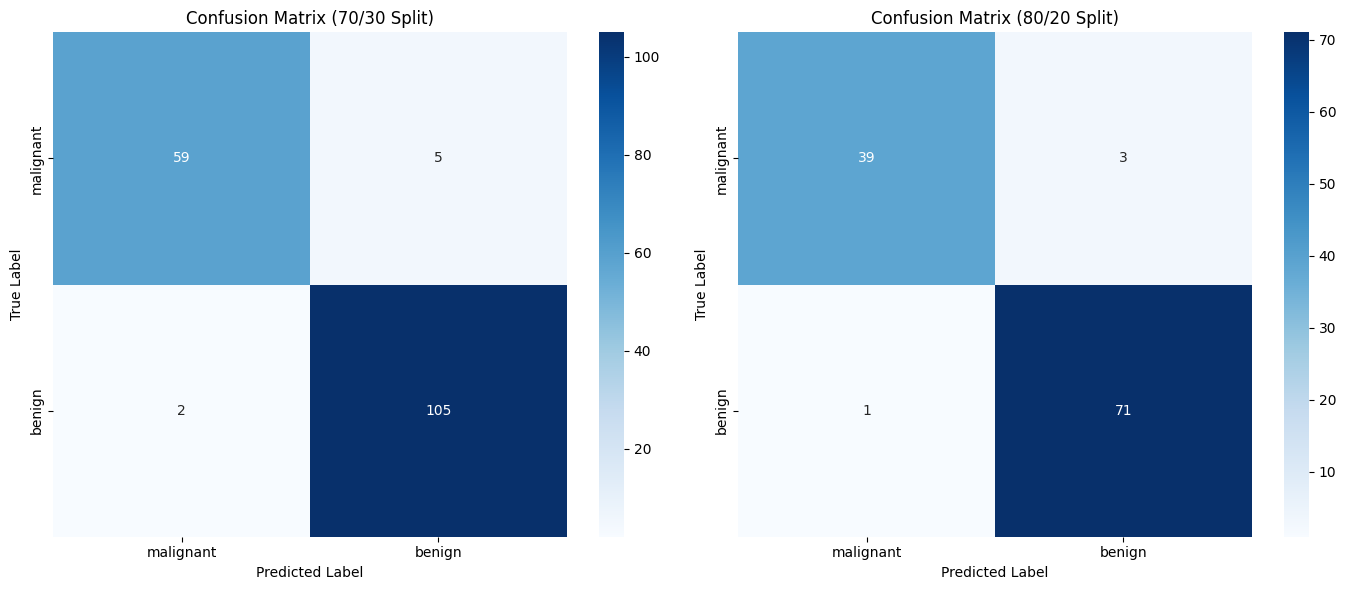

/tmp/ipykernel_1282/2793200723.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=splits, y=accuracies, palette='viridis')


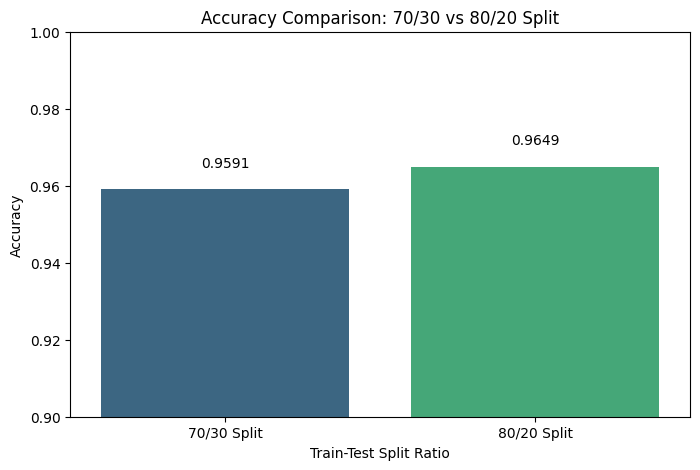

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Confusion Matrix for 70/30 Split
sns.heatmap(cm_70, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=breast_cancer.target_names, yticklabels=breast_cancer.target_names)
axes[0].set_title('Confusion Matrix (70/30 Split)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot Confusion Matrix for 80/20 Split
sns.heatmap(cm_80, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=breast_cancer.target_names, yticklabels=breast_cancer.target_names)
axes[1].set_title('Confusion Matrix (80/20 Split)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Accuracy Comparison Bar Chart
accuracies = [results['70/30 Split']['Accuracy'], results['80/20 Split']['Accuracy']]
splits = ['70/30 Split', '80/20 Split']

plt.figure(figsize=(8, 5))
sns.barplot(x=splits, y=accuracies, palette='viridis')
plt.title('Accuracy Comparison: 70/30 vs 80/20 Split')
plt.xlabel('Train-Test Split Ratio')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0) # Set y-axis limits to highlight differences
for index, value in enumerate(accuracies):
    plt.text(index, value + 0.005, f'{value:.4f}', ha='center', va='bottom')
plt.show()


### 12. Show Feature Importance Graph

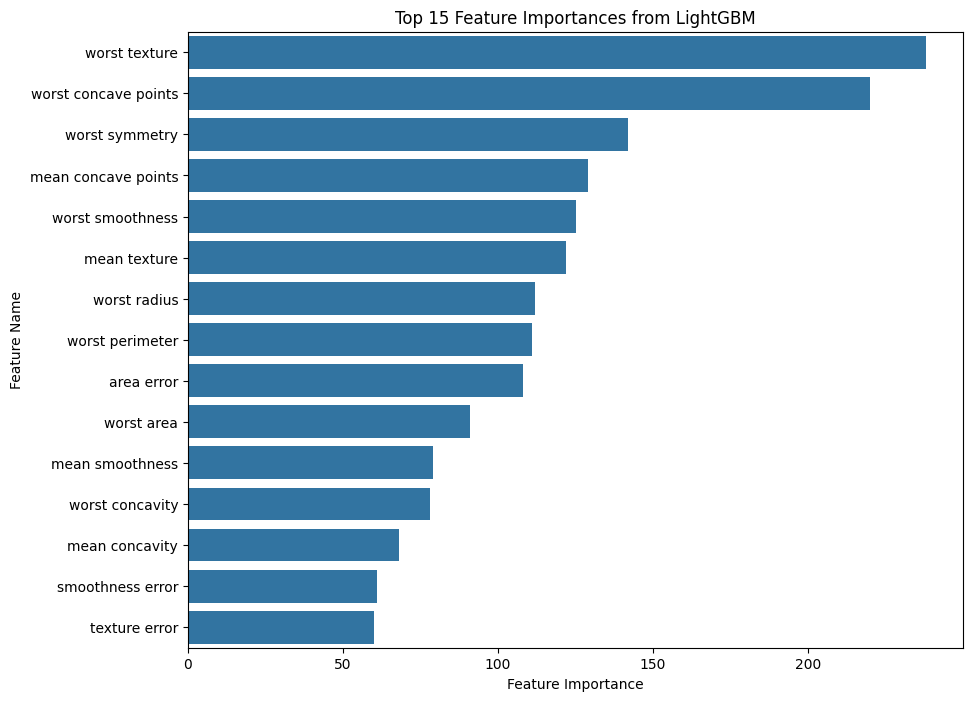

In [27]:
# Get feature importance from one of the models (e.g., 80/20 split model)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': lgbm_classifier_80.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
plt.title('Top 15 Feature Importances from LightGBM')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.show()


### 13. Print Conclusion

In [28]:
print("\n--- Conclusion ---")

# Which split performs better
accuracy_70 = results['70/30 Split']['Accuracy']
accuracy_80 = results['80/20 Split']['Accuracy']

if accuracy_80 > accuracy_70:
    better_split = '80/20 Split'
    better_accuracy = accuracy_80
    other_accuracy = accuracy_70
else:
    better_split = '70/30 Split'
    better_accuracy = accuracy_70
    other_accuracy = accuracy_80

print(f"Based on accuracy, the {better_split} (Accuracy: {better_accuracy:.4f}) performed slightly better than the {'70/30 Split' if better_split == '80/20 Split' else '80/20 Split'} (Accuracy: {other_accuracy:.4f}). This small difference might be due to more training data available in the 80/20 split, allowing the model to learn patterns more effectively, or simply random variation given the dataset size.")

# Why LightGBM performs well
print("\nWhy LightGBM performs well:")
print("LightGBM is a gradient boosting framework that uses tree-based learning algorithms. It is known for its high efficiency and speed, as well as its accuracy, especially on tabular data. Key reasons for its good performance include:")
print("  - **Gradient-based One-Side Sampling (GOSS):** It focuses on instances with larger gradients, effectively downsampling instances with small gradients without losing information.")
print("  - **Exclusive Feature Bundling (EFB):** It bundles mutually exclusive features to reduce the number of features, which speeds up training without significant loss of accuracy.")
print("  - **Leaf-wise tree growth:** Unlike level-wise growth in many other tree algorithms, LightGBM grows trees leaf-wise. This can lead to faster convergence and higher accuracy, especially on complex datasets, by focusing on the leaves that yield the maximum loss reduction.")
print("  - **Handling of Categorical Features:** LightGBM has efficient handling of categorical features without requiring one-hot encoding.")
print("  - **Parallel processing:** It supports parallel training, which further speeds up the process.")
print("For the Breast Cancer dataset, which has a moderate number of features and is well-structured, LightGBM's efficiency and ability to capture complex non-linear relationships make it a very suitable and effective algorithm.")



--- Conclusion ---
Based on accuracy, the 80/20 Split (Accuracy: 0.9649) performed slightly better than the 70/30 Split (Accuracy: 0.9591). This small difference might be due to more training data available in the 80/20 split, allowing the model to learn patterns more effectively, or simply random variation given the dataset size.

Why LightGBM performs well:
LightGBM is a gradient boosting framework that uses tree-based learning algorithms. It is known for its high efficiency and speed, as well as its accuracy, especially on tabular data. Key reasons for its good performance include:
  - **Gradient-based One-Side Sampling (GOSS):** It focuses on instances with larger gradients, effectively downsampling instances with small gradients without losing information.
  - **Exclusive Feature Bundling (EFB):** It bundles mutually exclusive features to reduce the number of features, which speeds up training without significant loss of accuracy.
  - **Leaf-wise tree growth:** Unlike level-wise 